<a href="https://colab.research.google.com/github/Brummelmayano/Compteur-intelligent/blob/main/model/code/detect_and_cut_scoreboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
import os
import cv2
import numpy as np
import sys
import glob
from tensorflow.lite.python.interpreter import Interpreter

import matplotlib
import matplotlib.pyplot as plt


# Définition de la fonction pour la détection et rognage avec le modèle TFLite et l'affichage des résultats
def tflite_detect_and_cut_scoreboard(modelpath, inputimg, lblpath, min_conf=0.5, savepath='/content/results', txt_only=False):

    # Chargement du modèle TensorFlow Lite en mémoire
    interpreter = Interpreter(model_path=modelpath)
    interpreter.allocate_tensors()

    # Récupération des détails du modèle
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    height = input_details[0]['shape'][1]
    width = input_details[0]['shape'][2]

    float_input = (input_details[0]['dtype'] == np.float32)

    input_mean = 127.5
    input_std = 127.5

    # Redimensionnement de l'image à la forme attendue [1xHxWx3]
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    imH, imW, _ = inputimg.shape
    image_resized = cv2.resize(image_rgb, (width, height))
    input_data = np.expand_dims(image_resized, axis=0)

    # Vérification si le modèle utilise des valeurs en virgule flottante
    if float_input:
        # Normalisation des valeurs de pixels
        input_data = (np.float32(input_data) - input_mean) / input_std

    # Réalisation de la détection en exécutant le modèle avec l'image en entrée
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()

    # Récupération des résultats de détection
    boxes = interpreter.get_tensor(output_details[1]['index'])[0]  # Coordonnées de la boîte englobante des objets détectés
    classes = interpreter.get_tensor(output_details[3]['index'])[0]  # Index de classe des objets détectés
    scores = interpreter.get_tensor(output_details[0]['index'])[0]  # Confiance des objets détectés

    detections = []

    # Boucle sur toutes les détections et dessin de la boîte de détection si la confiance est au-dessus du seuil minimum
    for i in range(len(scores)):
        if ((scores[i] > min_conf) and (scores[i] <= 1.0)):

            # Obtention des coordonnées de la boîte englobante et dessin de la boîte
            ymin = int(max(1, (boxes[i][0] * imH)))
            xmin = int(max(1, (boxes[i][1] * imW)))
            ymax = int(min(imH, (boxes[i][2] * imH)))
            xmax = int(min(imW, (boxes[i][3] * imW)))

            # Rogner la partie de l'image en fonction des coordonnées de la boîte de détection
            cropped_image = image_rgb[ymin:ymax, xmin:xmax]

            # Retourner l'image d'origine et l'image rognée dans un tuple
            return image_rgb, cropped_image

    # Aucune détection n'a été trouvée, retourner une valeur vide pour les deux
    return image_rgb, None


In [ ]:
#n'oubliez pas de changer le chemin de l'emplacement de votre image
# pour ce faire aller dans Fichier ensuite importer une image dans l'espace de stockage de la session
# une fois l'image importée, copier le chemn de l'images puis affectez à la variable  PATH_TO_IMAGE

PATH_TO_IMAGE = '/content/gdrive/MyDrive/Unikin/memoire/roidetection/scoreboard/match20.jpg'  # Vérifiez que ce chemin est correct

# Charger l'image et vérifier si elle a été chargée correctement
image = cv2.imread(PATH_TO_IMAGE)
if image is None:
    print("Erreur lors du chargement de l'image. Vérifiez le chemin du fichier.")
    # Arrêtez l'exécution si l'image n'a pas pu être chargée
    sys.exit()

PATH_TO_MODEL='/content/gdrive/MyDrive/Unikin/memoire/roidetection/custom_model_lite/saved_model/detect.tflite'   # Path to .tflite model file
PATH_TO_LABELS='/content/gdrive/MyDrive/Unikin/memoire/roidetection/custom_model_lite/saved_model/labelmap.txt'   # Path to labelmap.txt file
min_conf_threshold=0.5   # Confidence threshold (try changing this to 0.01 if you don't see any detection results)
images_to_test = 1   # Number of images to run detection on



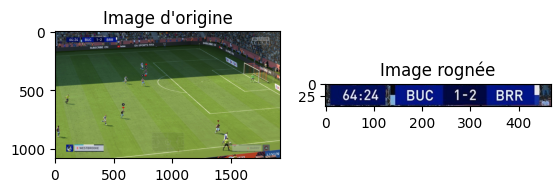

In [ ]:
original_image, cropped_image = tflite_detect_and_cut_scoreboard(PATH_TO_MODEL, image, PATH_TO_LABELS, min_conf_threshold)

# Vérifier si une détection a été effectuée
if original_image is not None and cropped_image is not None:
    # Afficher l'image d'origine
    plt.subplot(1, 2, 1)
    plt.imshow(original_image)
    plt.title('Image d\'origine')

    # Afficher l'image recadrée
    plt.subplot(1, 2, 2)
    plt.imshow(cropped_image)
    plt.title('Image rognée')
    cv2.imwrite('./roi_detecté/image_rognee.jpg', cv2.cvtColor(cropped_image, cv2.COLOR_RGB2BGR))


    plt.show()
elif original_image is not None and cropped_image is None:
    # Afficher l'image d'origine
    plt.subplot(1, 2, 1)
    plt.imshow(original_image)
    plt.title('Image d\'origine')


    print("Aucune détection n'a été effectuée.")
